# InfraBayesian vs Bayesian Agent Comparison

Compare the InfraBayesianAgent (non-KU, single a-measure) against the existing BayesianAgent across all environments.

**Agents compared** (on bandit-like environments):
- **BayesianAgent**: Gaussian precision-weighted updates
- **IB + GaussianBelief**: Same update math as BayesianAgent, wrapped in IB plumbing. Should be **identical** — proves the AMeasure/Infradistribution wrapping is a true no-op.
- **IB + BanditBelief**: Beta-Bernoulli conjugate prior (proper model for 0/1 rewards). Same IB framework, different statistical model.

**On Newcomb-like environments**: All three above use per-arm values and don't model the game. We add:
- **IB + NewcombLikeBelief**: Tracks the full reward matrix. Structural advantage because it models the predictor.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

from ibrl.simulators import simulate
from ibrl.utils import construct_environment
from ibrl.agents import BayesianAgent, InfraBayesianAgent
from ibrl.infrabayesian.beliefs import BanditBelief, GaussianBelief, NewcombLikeBelief

## Configuration

In [2]:
# Environments to test, grouped by type
bandit_envs = ["bandit", "switching"]
newcomb_envs = ["newcomb", "damascus", "asymmetric-damascus", "coordination", "pdbandit"]

all_envs = bandit_envs + newcomb_envs

options = {
    "num_actions": 2,
    "num_steps":   500,
    "num_runs":    20,
    "seed":        42,
    "verbose":     0,
}

def make_agent_specs(env_name):
    """Return dict of {name: agent} for the given environment.
    
    Each agent gets a fresh environment (same seed) so they see identical worlds.
    
    For bandit-like envs we compare three agents:
      - bayesian: existing BayesianAgent (Gaussian updates)
      - ib-gaussian: IB + GaussianBelief (should be IDENTICAL to bayesian)
      - ib-bernoulli: IB + BanditBelief (Beta-Bernoulli, proper model for 0/1 rewards)
      
    For Newcomb-like envs we add:
      - ib-newcomb: IB + NewcombLikeBelief (tracks full reward matrix)
    """
    n = options["num_actions"]
    shared = dict(num_actions=n, seed=options["seed"] + 0x01234567, epsilon=0.1)

    agents = {
        "bayesian":     BayesianAgent(**shared),
        "ib-gaussian":  InfraBayesianAgent(**shared, belief=GaussianBelief(num_actions=n)),
        "ib-bernoulli": InfraBayesianAgent(**shared, belief=BanditBelief(num_actions=n)),
    }

    if env_name in newcomb_envs:
        agents["ib-newcomb"] = InfraBayesianAgent(
            **shared, belief=NewcombLikeBelief(num_actions=n),
        )

    return agents

## Run experiments

In [3]:
all_results = {}

for env_name in all_envs:
    all_results[env_name] = {}
    agents = make_agent_specs(env_name)

    for agent_name, agent in agents.items():
        # Fresh environment per agent so they all see the same world
        env = construct_environment(env_name, options)
        label = f"{env_name} / {agent_name}"
        print(f"Running: {label}")

        results = simulate(env, agent, options)
        all_results[env_name][agent_name] = results

        print(f"  optimal: {results['optimal_reward']:.4f}  "
              f"final avg: {results['average_reward'][0, -1]:.4f}")

print("\nDone.")

Running: bandit / bayesian
  optimal: 0.7278  final avg: 0.7500
Running: bandit / ib-gaussian
  optimal: 0.7278  final avg: 0.7500
Running: bandit / ib-bernoulli
  optimal: 0.7278  final avg: 0.7500
Running: switching / bayesian
  optimal: 1.0000  final avg: 0.4500
Running: switching / ib-gaussian
  optimal: 1.0000  final avg: 0.4500
Running: switching / ib-bernoulli
  optimal: 1.0000  final avg: 0.5500
Running: newcomb / bayesian
  optimal: 1.0000  final avg: 0.6400
Running: newcomb / ib-gaussian
  optimal: 1.0000  final avg: 0.6400
Running: newcomb / ib-bernoulli
  optimal: 1.0000  final avg: 0.9550
Running: newcomb / ib-newcomb
  optimal: 1.0000  final avg: 0.9550
Running: damascus / bayesian
  optimal: 0.5000  final avg: 0.0500
Running: damascus / ib-gaussian
  optimal: 0.5000  final avg: 0.0500
Running: damascus / ib-bernoulli
  optimal: 0.5000  final avg: 0.1500
Running: damascus / ib-newcomb
  optimal: 0.5000  final avg: 0.4500
Running: asymmetric-damascus / bayesian
  optimal: 

## Cumulative regret comparison

One subplot per environment. All agents plotted together. On bandit/switching, the bayesian and ib-gaussian curves should overlap perfectly.

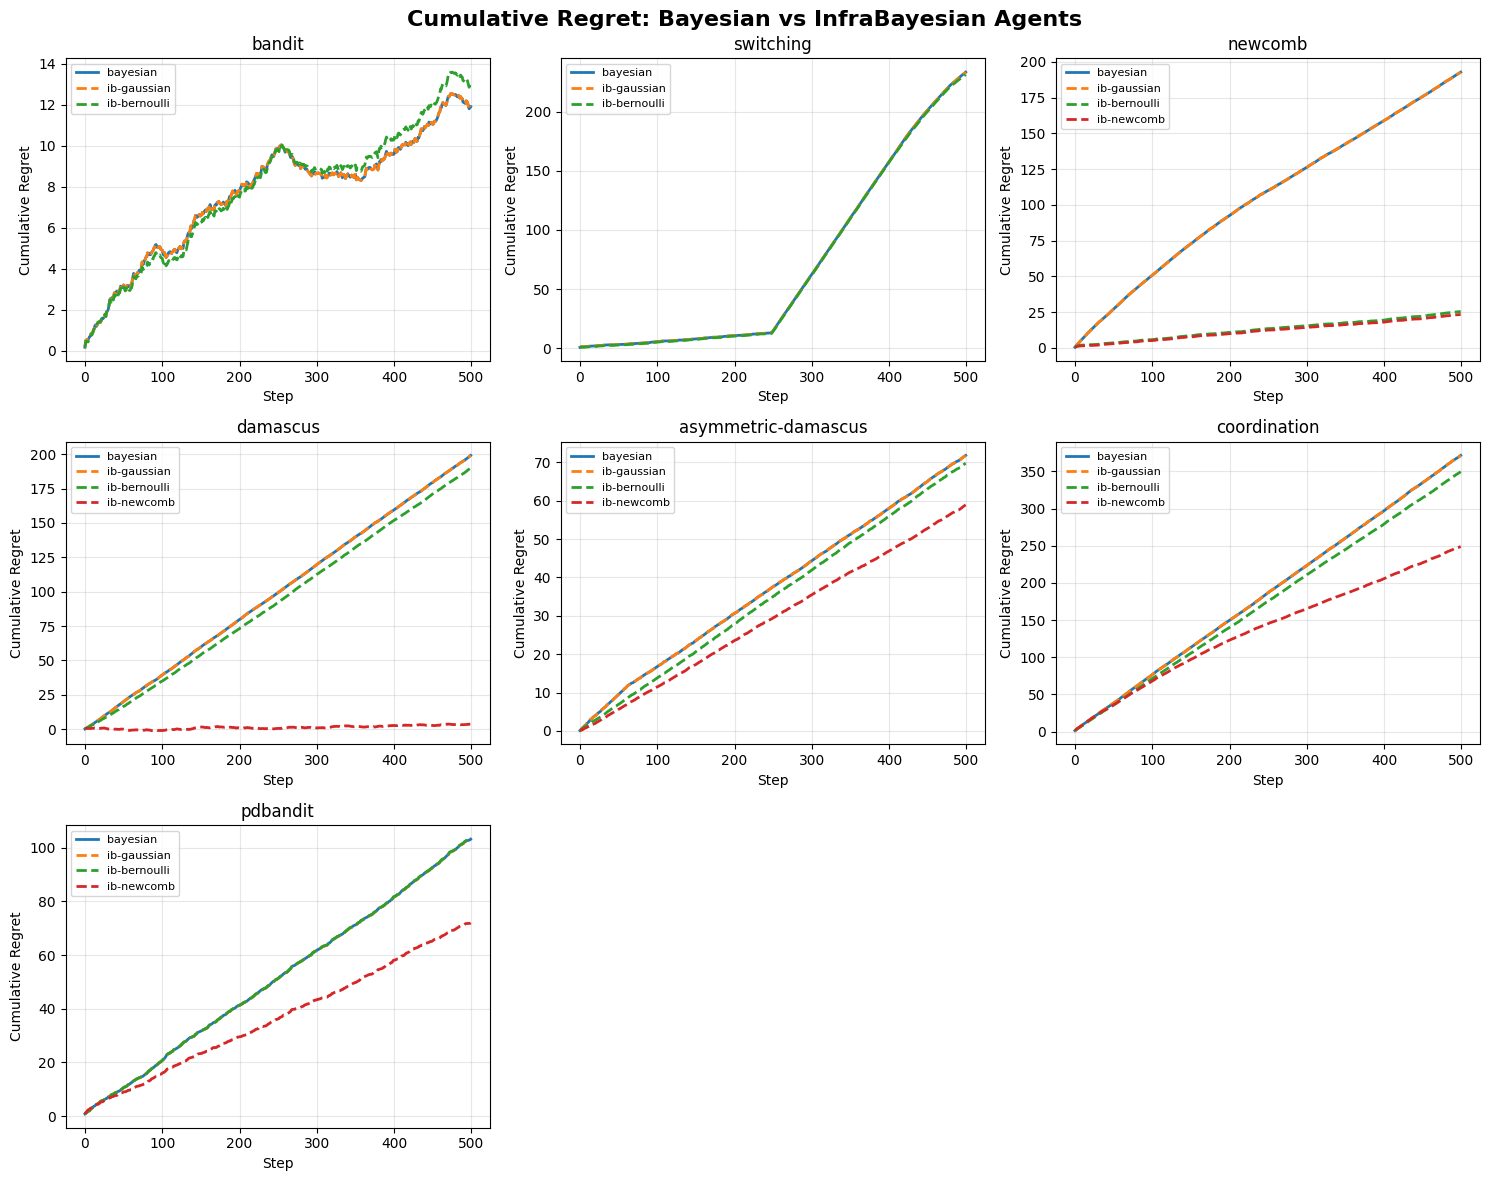

In [7]:
cols = 3
rows = math.ceil(len(all_envs) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, env_name in enumerate(all_envs):
    ax = axes[i]
    for agent_name, res in all_results[env_name].items():
        avg_reward = res["average_reward"][0, :]
        optimal = res["optimal_reward"]
        cumulative_regret = np.cumsum(optimal - avg_reward)
        if "ib-" in agent_name:
            ls="--"
        else:
            ls="-"
        ax.plot(cumulative_regret, label=agent_name, linewidth=2, ls=ls)
    ax.set_title(env_name)
    ax.set_xlabel("Step")
    ax.set_ylabel("Cumulative Regret")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for j in range(len(all_envs), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Cumulative Regret: Bayesian vs InfraBayesian Agents", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Selection probabilities

Per-agent, per-environment view of how the policy evolves over time.

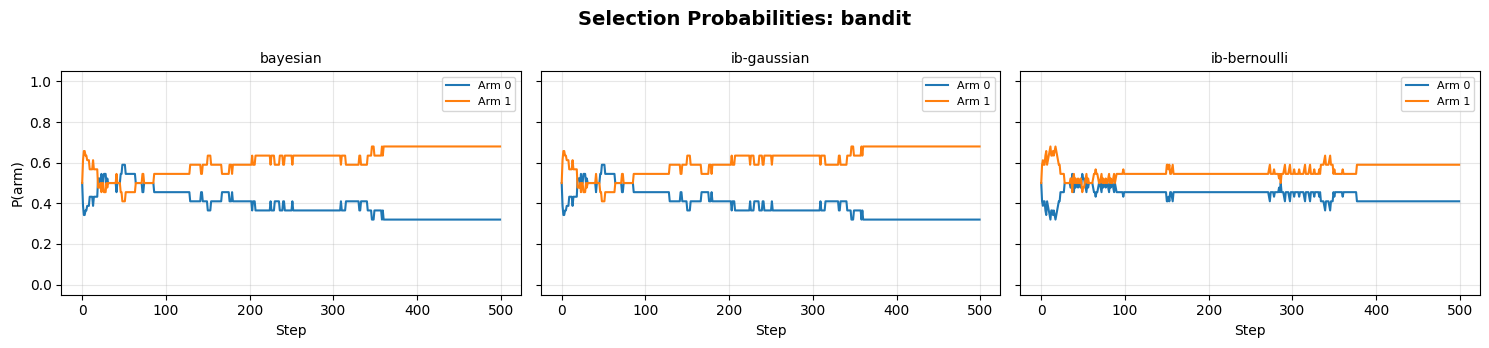

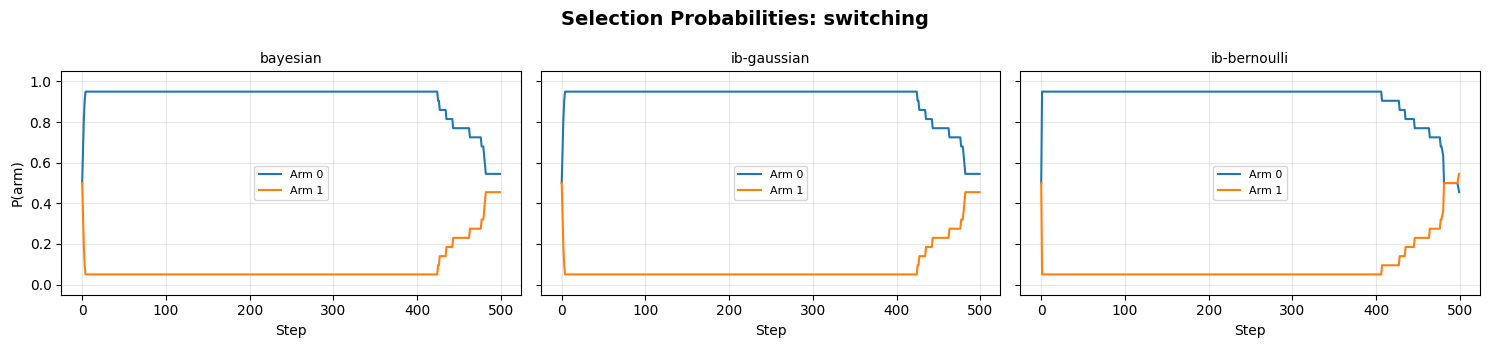

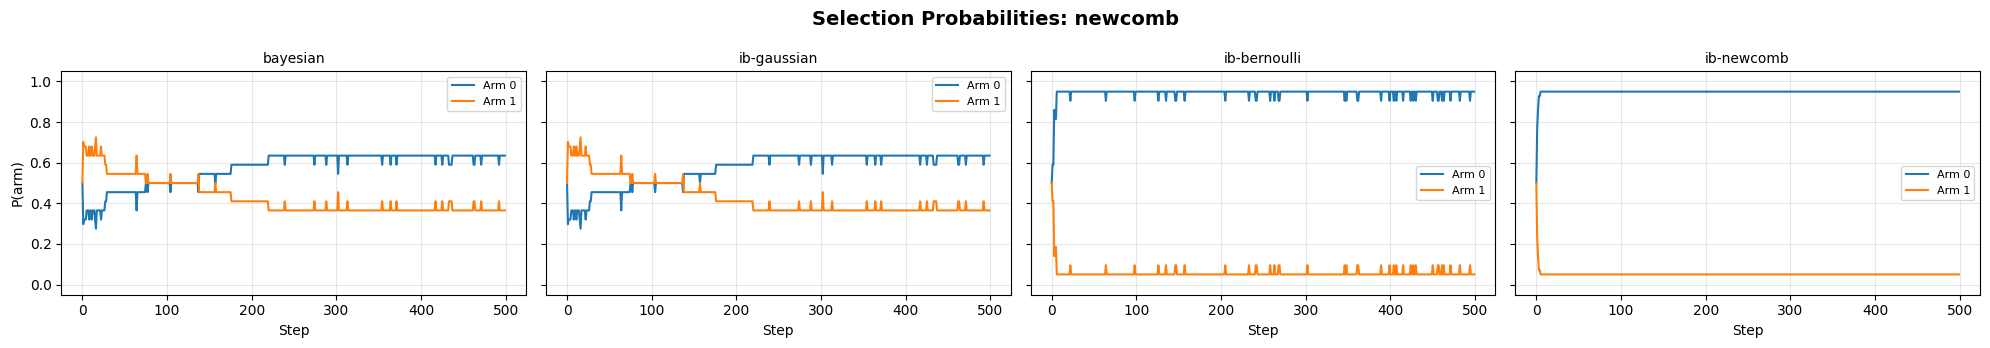

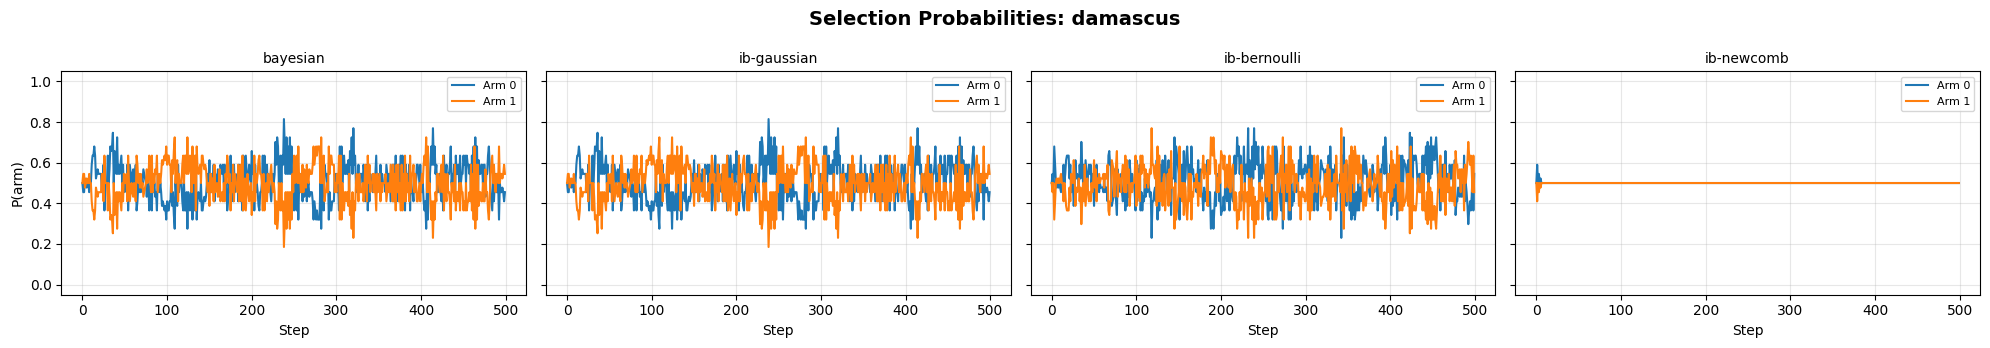

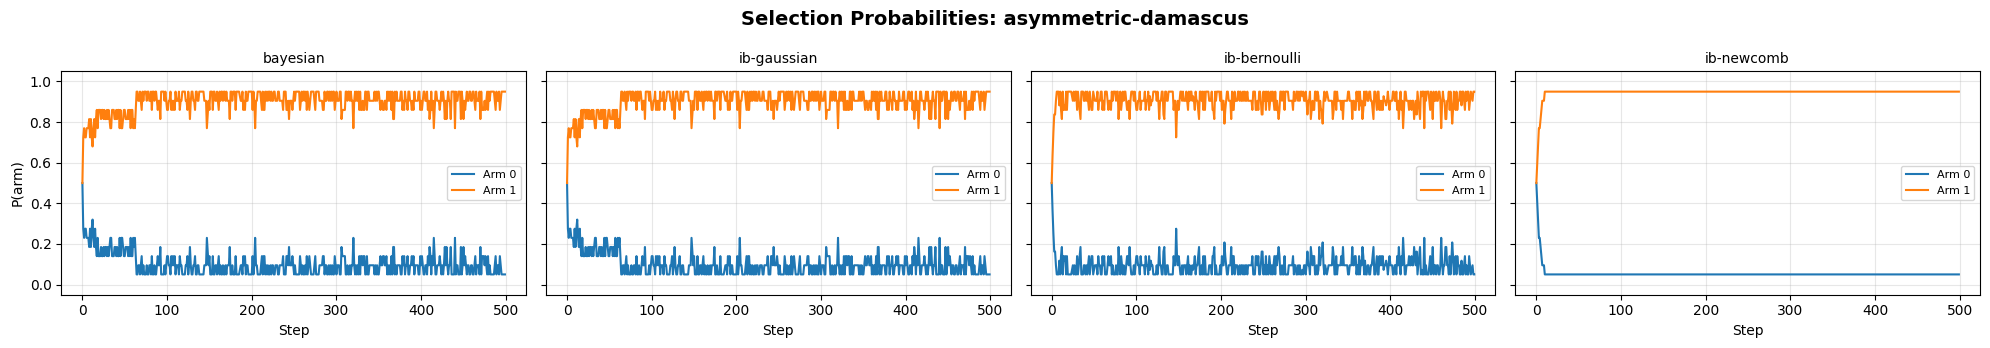

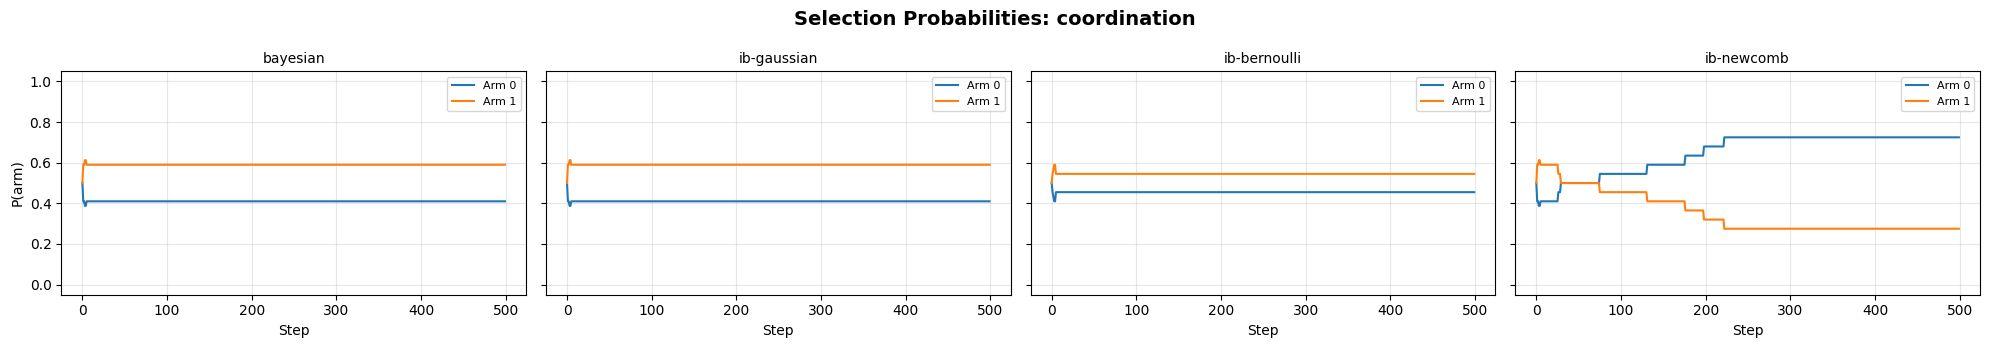

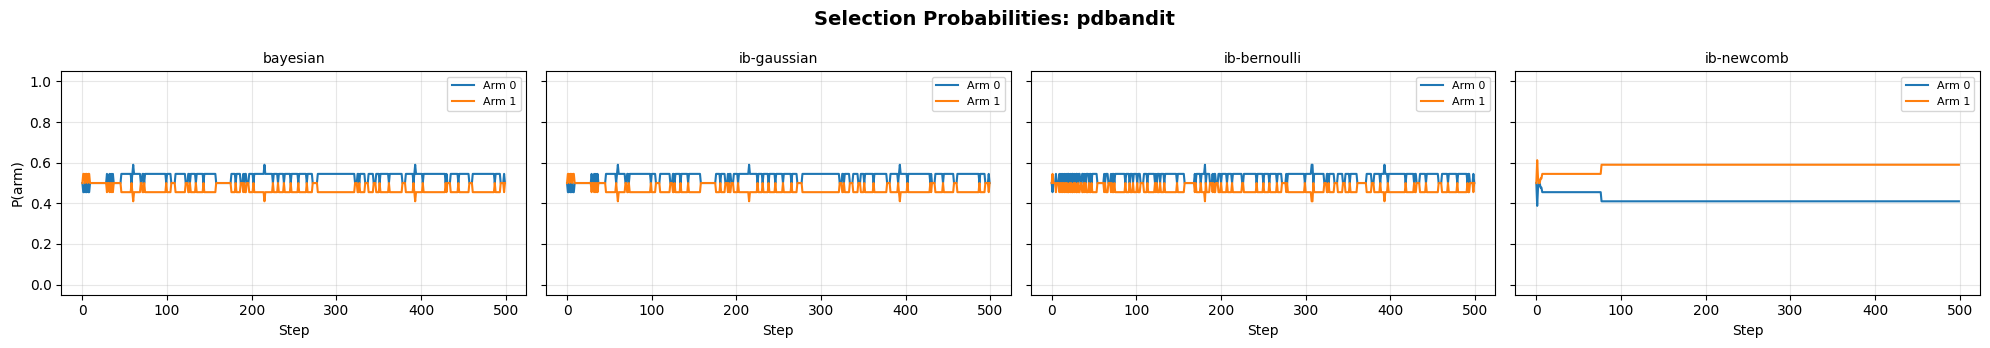

In [5]:
k = options["num_actions"]

for env_name in all_envs:
    agent_names = list(all_results[env_name].keys())
    n_agents = len(agent_names)
    fig, axes = plt.subplots(1, n_agents, figsize=(5 * n_agents, 3.5), sharey=True)
    if n_agents == 1:
        axes = [axes]
    fig.suptitle(f"Selection Probabilities: {env_name}", fontsize=14, fontweight="bold")

    for j, agent_name in enumerate(agent_names):
        ax = axes[j]
        res = all_results[env_name][agent_name]
        for arm in range(k):
            ax.plot(res["probabilities"][:, :, arm].mean(axis=0), label=f"Arm {arm}")
        ax.set_title(agent_name, fontsize=10)
        ax.set_xlabel("Step")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        if j == 0:
            ax.set_ylabel("P(arm)")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## Summary table

In [6]:
# Collect all agent names across environments
all_agent_names = sorted(set(
    name for env_results in all_results.values() for name in env_results
))

header = f"{'Environment':<25} {'Optimal':>8}"
for name in all_agent_names:
    header += f" {name:>14}"
print(header)
print("-" * len(header))

for env_name in all_envs:
    optimal = list(all_results[env_name].values())[0]["optimal_reward"]
    row = f"{env_name:<25} {optimal:>8.3f}"
    for name in all_agent_names:
        if name in all_results[env_name]:
            avg = all_results[env_name][name]["average_reward"][0, -50:].mean()
            row += f" {avg:>14.3f}"
        else:
            row += f" {'—':>14}"
    print(row)

Environment                Optimal       bayesian   ib-bernoulli    ib-gaussian     ib-newcomb
----------------------------------------------------------------------------------------------
bandit                       0.728          0.712          0.708          0.712              —
switching                    1.000          0.346          0.366          0.346              —
newcomb                      1.000          0.654          0.935          0.654          0.942
damascus                     0.500          0.100          0.116          0.100          0.480
asymmetric-damascus          0.667          0.529          0.530          0.529          0.542
coordination                 2.000          1.257          1.286          1.257          1.561
pdbandit                     0.776          0.560          0.560          0.560          0.639
